[Home](../../README.md)

### Model Training - Polynomial Regression

Linear regression assumes the data has a linear pattern. If your data does not have a linear pattern you can consider a polynomial regression algorithm that provides a multi (poly) coefficient linear relationship between an independent variable and a dependent variable to predict the outcome of future events. We will now Train a Polynomial regression algorithm on the features you have engineered to see how closely we can predict the health outcomes for individuals.

#### Step 1

Load the required dependencies:

In [9]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pickle

In [10]:
training_data = pd.read_csv('AA_training_data.csv')


#### Step 2

Store the data columns for Linear Regression.

In [11]:
x_name = ['Platform', 'Publisher']
y_name = 'Global_Sales'
x = np.array(training_data[x_name])
y = np.array(training_data[y_name])

#### Step 3

Plot the feature `x` and target `y` data on a graph using the column headings as the graph labels.

In [12]:
#for some reason this code keeps taking ages to run and throwing an error - the predictions graphs run fine, so I'm just commenting this out for now
#if(len(x_name) == 1):
#    plt.scatter(x, y, marker='x', c='r')
#    plt.title("Global sales vs publisher")
#    plt.ylabel(f'Training {y}')
#    plt.xlabel(f'Training {x[0]}')
#else:
#    fig,ax=plt.subplots(1,len(x),figsize=(12,3))
#    for i in range(len(ax)):
#        ax[i].scatter(x[:,i],y, label = 'Global_Sales')
#        ax[i].set_xlabel(x[i])
#    ax[0].set_ylabel("Global_Sales"); ax[0].legend();
#    fig.suptitle("Global sales vs... a lot.")
#plt.show()

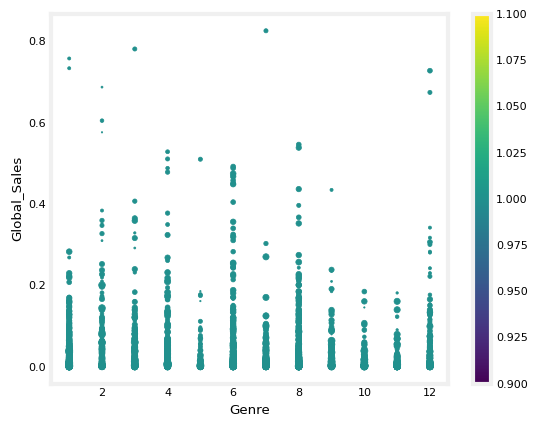

In [13]:
ax = plt.scatter(training_data.Genre, training_data.Global_Sales, training_data.Platform, training_data.Publisher)
plt.xlabel("Genre")
plt.ylabel("Global_Sales")
plt.colorbar()
plt.show()

#### Step 4

Then save an instance of PolynomialFeatures, adjust the 'degree' parameter to suit your model and create the feature using the data in 'x'. (Note a degree of 1 is linear regression, each extra degree adds a coefficient).

Then use the [Scikit-learn](https://scikit-learn.org/stable/) library to instantiate a Machine Learning model class and store it in the `my_model` variable as an object.

In [14]:
poly = PolynomialFeatures(degree=3, include_bias=False)
poly_features = poly.fit_transform(x)

# Create the model
my_model = LinearRegression()
# Fit the model to the data
my_model.fit(poly_features, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Text(0.5, 0, 'Training Platform')

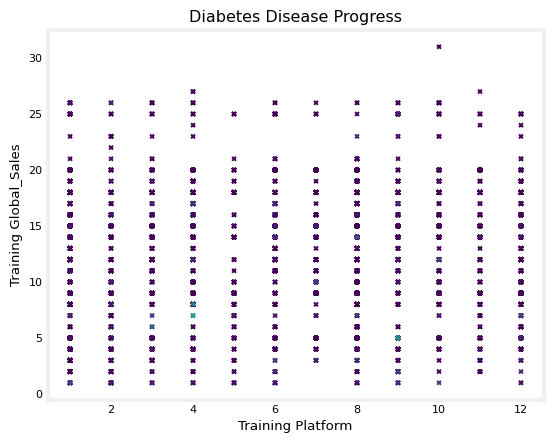

In [15]:
y_pred = my_model.predict(poly_features)
plt.scatter(training_data.Genre, training_data.Platform, training_data.Publisher, y_pred)
plt.scatter(training_data.Genre, training_data.Platform, training_data.Publisher, y, marker='x')
plt.title("Diabetes Disease Progress")
plt.ylabel(f'Training {y_name}')
plt.xlabel(f'Training {x_name[0]}')

In [20]:
new_game = pd.DataFrame({
    'Genre': [1],
    'Platform': [3]
})
new_poly_features = poly.fit_transform(new_game)
new_game['Global_Sales'] = my_model.predict(new_poly_features)

scale_feature = new_game['Global_Sales']

MIN_NG = 0

MAX_NG = 30

#scale features
newgame = (scale_feature + MIN_NG) * (MAX_NG + MIN_NG) 

print(f"New game data:\n{newgame}")



New game data:
0    0.684747
Name: Global_Sales, dtype: float64


In [21]:
#calculating the model intercept and coefficient
print(f'X Axis intercept: {my_model.intercept_}')
print(f'Coefficient: {my_model.coef_}')

X Axis intercept: 0.04805658901899449
Coefficient: [-2.01703442e-03 -1.07809083e-16  2.50775351e-04 -2.01703442e-03
  0.00000000e+00 -1.33422506e-05  2.50775351e-04 -2.01703442e-03
  0.00000000e+00]


#### Step 5

Plot the features, targets and model (linear regression).

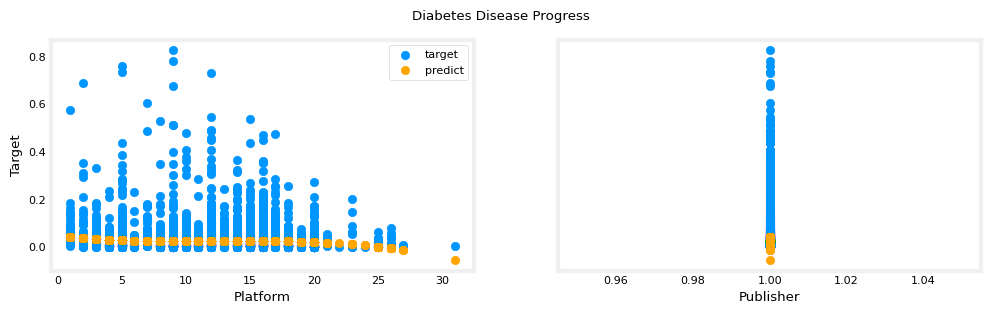

In [17]:
y_pred = my_model.predict(poly_features)
if(len(x_name) == 1):
    plt.scatter(x, y_pred)
    plt.scatter(x, y, marker='x', c='r')
    plt.title("Diabetes Disease Progress")
    plt.ylabel(f'Training {y_name}')
    plt.xlabel(f'Training {x_name[0]}')
else:
    fig,ax=plt.subplots(1,len(x_name),figsize=(12,3),sharey=True)
    for i in range(len(ax)):
        ax[i].scatter(x[:,i],y, label = 'target')
        ax[i].set_xlabel(x_name[i])
        ax[i].scatter(x[:,i],y_pred,color="orange", label = 'predict')
    ax[0].set_ylabel("Target"); ax[0].legend();
    fig.suptitle("Diabetes Disease Progress")
plt.show()

In [18]:
# save the poly to disk
#poly_filename = 'my_saved_poly_v3.pkl'
#pickle.dump(poly, open('../2.4.Model_Testing_and_Validation/' + poly_filename, 'wb'))

# save the model to disk
#model_filename = 'my_saved_model_v3.sav'
#pickle.dump(my_model, open('../2.4.Model_Testing_and_Validation/' + model_filename, 'wb'))

#### Step 6. Explore polynomial degrees

Students should now use the best features from Multiple Fetaure Linear Regression and apply some polynomial degrees to see if they can further improve the intuation of their model without overfitting.